In [1]:
import xarray as xr
import rioxarray
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.ndimage import median_filter, minimum_filter, maximum_filter, uniform_filter
import lightgbm as lgb 
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.cluster import KMeans

In [2]:
df = pd.read_parquet('../data/silver/Xy.parquet')
print("# rows:", len(df))
df.head(1)

# rows: 2400918


,lon,lat,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,red_5x5_var,...,cloud_confidence_3x3_max,cloud_confidence_3x3_var,cloud_confidence_5x5_median,cloud_confidence_5x5_min,cloud_confidence_5x5_max,cloud_confidence_5x5_var,cloud_confidence,scene_classification,valid_observations,ethz_map
0,-1.321577,7.622626,11,0,12,21,11,0,15,26,...,0,0,0,0,0,0,0,5,7,0.0


# Prep df

In [55]:
df = df.dropna(subset=('ethz_map'))

In [56]:
df = df.sample(10_000)

In [57]:
# Convert bands to 0-1 values
band_cols = [e for e in df.columns if e not in ('lon', 'lat', 'ethz_map')]
band_cols = [e for e in band_cols if not any(e.startswith(prefix) for prefix in ('cloud_confidence', 'scene_classification', 'valid_observations'))]
df[band_cols] /= 255
df.head(1)

,lon,lat,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,red_5x5_var,...,cloud_confidence_3x3_max,cloud_confidence_3x3_var,cloud_confidence_5x5_median,cloud_confidence_5x5_min,cloud_confidence_5x5_max,cloud_confidence_5x5_var,cloud_confidence,scene_classification,valid_observations,ethz_map
48210,-0.824956,7.477778,0.039216,0.023529,0.047059,0.011765,0.039216,0.023529,0.05098,0.011765,...,0,0,0,0,0,0,0,5,5,0.0


# Split in train:test

In [59]:
n_splits = 100
kmeans = KMeans(n_clusters=n_splits, random_state=42, n_init=10)
df['spatial_fold'] = kmeans.fit_predict(df[['lat', 'lon']])

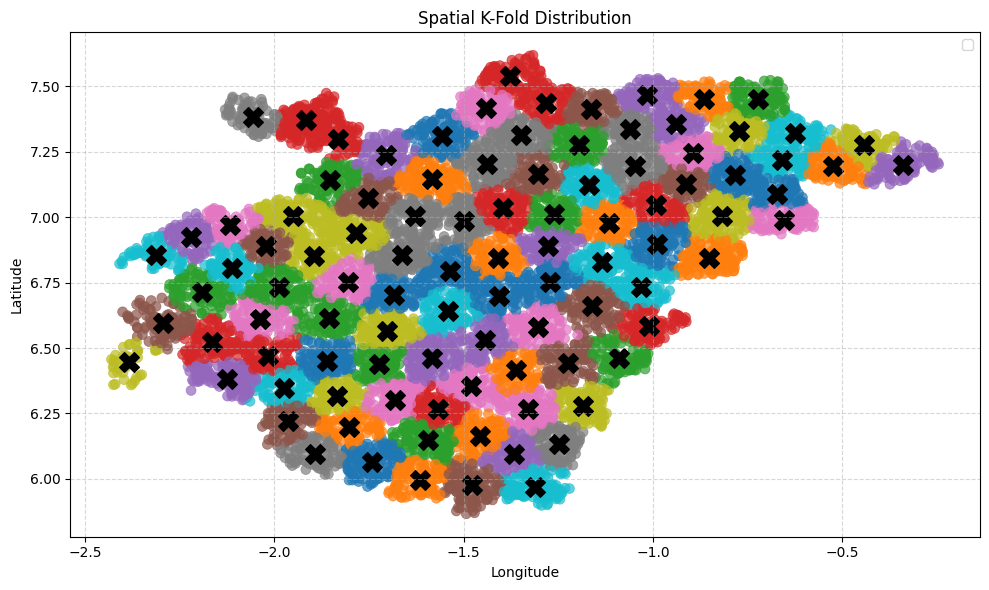

In [60]:
# Plot the folds
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='lon', y='lat', hue='spatial_fold', palette='tab10', s=50, alpha=0.7, edgecolor=None)

# Plot the centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 1], centroids[:, 0], c='black', s=200, marker='X', label='Centroids')

plt.title('Spatial K-Fold Distribution')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend([])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

In [61]:
# Randomly keep some folds as test set
def train_test_split(df):
    test_mask = df.spatial_fold.isin(range(10))
    train_df = df[~test_mask]
    test_df = df[test_mask]

    return train_df, test_df

train_df, test_df = train_test_split(df)

# Train models

In [63]:
def get_Xy(df):
    X = df.drop(columns=["ethz_map"])
    y = df["ethz_map"]
    return X, y

X_train, y_train = get_Xy(train_df)
X_test, y_test = get_Xy(test_df)

In [64]:
import numpy as np
import pandas as pd
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, f1_score, precision_score, recall_score

dummy_regr = DummyRegressor(strategy="mean")
dummy_regr.fit(X_train, y_train)
yhat_test = dummy_regr.predict(X_test)

print(f"Dummy Constant Value: {dummy_regr.constant_[0][0]:.4f}")
print(f"Baseline MSE: {mean_squared_error(y_test, yhat_test):.4f}")
print(f"Baseline MAE: {mean_absolute_error(y_test, yhat_test):.4f}")
print('---'*3)
yhat_test = yhat_test > 0.5
y_test = y_test > 0.65
print(f"Baseline Macro F1: {f1_score(y_test, yhat_test, average='macro', zero_division=0):.4f}")
print(f"Baseline Macro Precision: {precision_score(y_test, yhat_test, average='macro', zero_division=0):.4f}")
print(f"Baseline Macro Recall: {recall_score(y_test, yhat_test, average='macro', zero_division=0):.4f}")

Dummy Constant Value: 0.3008
Baseline MSE: 0.1354
Baseline MAE: 0.3329
---------
Baseline Macro F1: 0.4405
Baseline Macro Precision: 0.3937
Baseline Macro Recall: 0.5000


In [65]:
# Build X,y

# Initialize and fit the Dummy Classifier
dummy_clf = DummyClassifier(strategy="stratified")
dummy_clf.fit(X_train, y_train > 0.65)
yhat_test = dummy_clf.predict(X_test)

# Evaluate the baseline
print(f"Baseline Macro F1: {f1_score(y_test, yhat_test, average='macro', zero_division=0):.4f}")
print(f"Baseline Macro Precision: {precision_score(y_test, yhat_test, average='macro', zero_division=0):.4f}")
print(f"Baseline Macro Recall: {recall_score(y_test, yhat_test, average='macro', zero_division=0):.4f}")
print("- Negative (0)")
print(f"- F1: {f1_score(y_test, yhat_test, pos_label=0, zero_division=0):.4f}")
print(f"-- Precision: {precision_score(y_test, yhat_test, pos_label=0, zero_division=0):.4f}")
print(f"-- Recall: {recall_score(y_test, yhat_test, pos_label=0, zero_division=0):.4f}")
print("- Positive (1)")
print(f"- F1: {f1_score(y_test, yhat_test, pos_label=1, zero_division=0):.4f}")
print(f"-- Precision: {precision_score(y_test, yhat_test, pos_label=1, zero_division=0):.4f}")
print(f"-- Recall: {recall_score(y_test, yhat_test, pos_label=1, zero_division=0):.4f}")

Baseline Macro F1: 0.5108
Baseline Macro Precision: 0.5113
Baseline Macro Recall: 0.5128
- Negative (0)
- F1: 0.7716
-- Precision: 0.7931
-- Recall: 0.7513
- Positive (1)
- F1: 0.2500
-- Precision: 0.2296
-- Recall: 0.2744


# Prep hyperparam optimization

In [67]:
import optuna
import lightgbm as lgb
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score, precision_score, recall_score

def optuna_objective_factory(X, y):
    def objective(trial):
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 2, 15),
            'num_leaves': trial.suggest_int('num_leaves', 10, 256),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
            'n_jobs': -1,
            'verbose': -1,
            'random_state': 42
        }
        
        
        # Use cross-validation to evaluate the parameters on the training data
        model = lgb.LGBMClassifier(**param)
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(model, X, y, cv=cv, scoring='f1_macro', n_jobs=1)
        
        return scores.mean()

    return objective

# Train LGBM baseline

In [68]:
df.head(1)

,lon,lat,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,red_5x5_var,...,cloud_confidence_3x3_var,cloud_confidence_5x5_median,cloud_confidence_5x5_min,cloud_confidence_5x5_max,cloud_confidence_5x5_var,cloud_confidence,scene_classification,valid_observations,ethz_map,spatial_fold
48210,-0.824956,7.477778,0.039216,0.023529,0.047059,0.011765,0.039216,0.023529,0.05098,0.011765,...,0,0,0,0,0,0,5,5,0.0,81


In [70]:
# Split
features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]

train_df, test_df = train_test_split(df)

X_train = train_df[features]
y_train = train_df["ethz_map"] > 0.65

X_test = test_df[features]
y_test = test_df["ethz_map"] > 0.65

X_train.head(2)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22
48210,0.027451,0.035294,0.039216,0.105882,0.082353,0.090196,0.066667,0.090196,0.141176,0.105882
2073563,0.015686,0.031373,0.027451,0.105882,0.141176,0.168627,0.129412,0.168627,0.113725,0.058824


In [72]:
def train_test_lgbm(X_train, y_train, X_test, y_test, n_trials=3):
    print("Starting Optuna hyperparameter optimization...")
    study = optuna.create_study(direction="maximize") 
    study.optimize(optuna_objective_factory(X_train, y_train), n_trials=n_trials, show_progress_bar=True)
    
    # Build final model
    clf = lgb.LGBMClassifier(**study.best_params)
    clf.fit(X_train, y_train)
    
    yhat_train = clf.predict(X_train)
    yhat_test = clf.predict(X_test)
    
    print("\n--- OPTIMIZED MODEL EVALUATION ---")
    print("TRAIN")
    print(f"- Macro F1: {f1_score(y_train, yhat_train, average='macro', zero_division=0):.4f}")
    print(f"- Macro Precision: {precision_score(y_train, yhat_train, average='macro', zero_division=0):.4f}")
    print(f"- Macro Recall: {recall_score(y_train, yhat_train, average='macro', zero_division=0):.4f}")
    
    print("\nTEST")
    print(f"- Macro F1: {f1_score(y_test, yhat_test, average='macro', zero_division=0):.4f}")
    print(f"- Macro Precision: {precision_score(y_test, yhat_test, average='macro', zero_division=0):.4f}")
    print(f"- Macro Recall: {recall_score(y_test, yhat_test, average='macro', zero_division=0):.4f}")

    return clf, yhat_train, yhat_test

train_test_lgbm(X_train, y_train, X_test, y_test);

[I 2026-06-17 12:19:14,686] A new study created in memory with name: no-name-cfae331a-5865-468f-8953-fb9b8a6040d2


Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-17 12:19:20,406] Trial 0 finished with value: 0.7641516514223271 and parameters: {'n_estimators': 427, 'learning_rate': 0.03500464500570659, 'max_depth': 15, 'num_leaves': 102, 'subsample': 0.7695771199350603, 'colsample_bytree': 0.9428353630550657, 'min_child_samples': 75}. Best is trial 0 with value: 0.7641516514223271.
[I 2026-06-17 12:19:22,916] Trial 1 finished with value: 0.7750082152712462 and parameters: {'n_estimators': 359, 'learning_rate': 0.022263021433779732, 'max_depth': 6, 'num_leaves': 253, 'subsample': 0.6315657376929822, 'colsample_bytree': 0.736702126594426, 'min_child_samples': 29}. Best is trial 1 with value: 0.7750082152712462.
[I 2026-06-17 12:19:29,812] Trial 2 finished with value: 0.7660985144355785 and parameters: {'n_estimators': 316, 'learning_rate': 0.020728013400618923, 'max_depth': 10, 'num_leaves': 105, 'subsample': 0.5551795944758078, 'colsample_bytree': 0.865390736788198, 'min_child_samples': 46}. Best is trial 1 with value: 0.77500821527124

# Consider the SCL

In [73]:
# The SCL flags a lot of px as cloud and whatnot, but not vegetation
df['scene_classification'] = df.scene_classification.map({
    0: 'NO_DATA',
    1: 'DEFECTIVE_PX',
    2: 'TOPO_SHADOW',
    3: 'CLOUD_SHADOW',
    4: 'VEGETATION',
    5: 'NOT_VEGETATED',
    6: 'WATER',
    7: 'UNCLASSIFIED',
    8: 'CLOUD_MED_PROB',
    9: 'CLOUD_HIGH_PROB',
    10: 'THIN_CIRRUS',
    11: 'SNOW_OR_ICE',
})
df[['scene_classification']].head(1)

,scene_classification
48210,NOT_VEGETATED


<Axes: xlabel='scene_classification', ylabel='Proportion'>

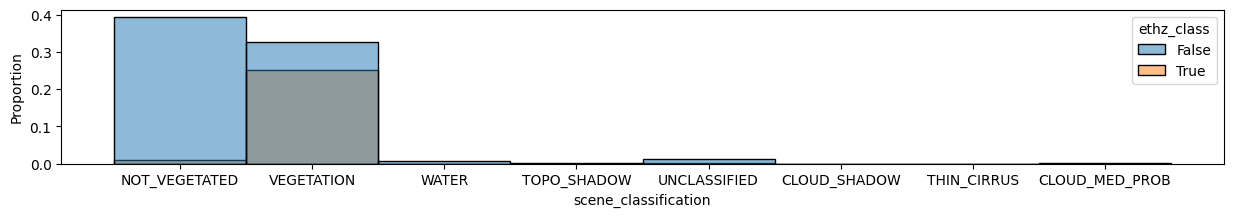

In [75]:
# There are points that are not vegetated, BUT considered as "cocoa" 
plt.figure(figsize=(15,2))
df["ethz_class"] = df.ethz_map > 0.65
sns.histplot(x="scene_classification", hue='ethz_class', data=df, stat="proportion")

In [76]:
# Ditch defective points
mask = df.scene_classification == "NO_DATA"
mask |= df.scene_classification == "DEFECTIVE_PX"
print(f"Discarded {mask.sum()}/{len(df)} ({mask.sum() / len(df) * 100:.2f}%) points")
df = df[~mask]
df.head(1)

Discarded 0/10000 (0.00%) points


,lon,lat,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,red_5x5_var,...,cloud_confidence_5x5_median,cloud_confidence_5x5_min,cloud_confidence_5x5_max,cloud_confidence_5x5_var,cloud_confidence,scene_classification,valid_observations,ethz_map,spatial_fold,ethz_class
48210,-0.824956,7.477778,0.039216,0.023529,0.047059,0.011765,0.039216,0.023529,0.05098,0.011765,...,0,0,0,0,0,NOT_VEGETATED,5,0.0,81,False


In [77]:
# Ditch clouds
mask = df.scene_classification == "CLOUD_MED_PROB"
mask |= df.scene_classification == "CLOUD_HIGH_PROB"
mask |= df.scene_classification == "THIN_CIRRUS"
print(f"Discarded {mask.sum()}/{len(df)} ({mask.sum() / len(df) * 100:.2f}%) points")
df = df[~mask]
df.head(1)

Discarded 4/10000 (0.04%) points


,lon,lat,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,red_5x5_var,...,cloud_confidence_5x5_median,cloud_confidence_5x5_min,cloud_confidence_5x5_max,cloud_confidence_5x5_var,cloud_confidence,scene_classification,valid_observations,ethz_map,spatial_fold,ethz_class
48210,-0.824956,7.477778,0.039216,0.023529,0.047059,0.011765,0.039216,0.023529,0.05098,0.011765,...,0,0,0,0,0,NOT_VEGETATED,5,0.0,81,False


In [78]:
# Split
features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]

# Split spatially
train_df, test_df = train_test_split(df)
X_train = train_df[features]
y_train = train_df["ethz_map"] > 0.65
X_test = test_df[features]
y_test = test_df["ethz_map"] > 0.65

train_test_lgbm(X_train, y_train, X_test, y_test);

[I 2026-06-17 12:19:57,782] A new study created in memory with name: no-name-0b6e99fe-7906-45ff-a244-c934acecfd2d


Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-17 12:19:59,603] Trial 0 finished with value: 0.7704174593746329 and parameters: {'n_estimators': 232, 'learning_rate': 0.05080863817874157, 'max_depth': 8, 'num_leaves': 178, 'subsample': 0.5445178820371264, 'colsample_bytree': 0.8805593100292228, 'min_child_samples': 64}. Best is trial 0 with value: 0.7704174593746329.
[I 2026-06-17 12:20:02,089] Trial 1 finished with value: 0.7701795780431943 and parameters: {'n_estimators': 465, 'learning_rate': 0.03562696910487169, 'max_depth': 8, 'num_leaves': 20, 'subsample': 0.7980465854302454, 'colsample_bytree': 0.7489568250363834, 'min_child_samples': 99}. Best is trial 0 with value: 0.7704174593746329.
[I 2026-06-17 12:20:09,202] Trial 2 finished with value: 0.7669683311728963 and parameters: {'n_estimators': 240, 'learning_rate': 0.049078402734347944, 'max_depth': 11, 'num_leaves': 120, 'subsample': 0.6800666117200503, 'colsample_bytree': 0.7352958449719479, 'min_child_samples': 11}. Best is trial 0 with value: 0.770417459374632

# Add TCI

In [80]:
# Add TCI
df["tci"] = 1.2 * (df["rededge"] - df["green"]) - 1.5 * (df["red"] - df["green"]) * np.sqrt(df["rededge"] / df["red"])

In [81]:
# Split
features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"] + ["tci"]

# Split spatially
train_df, test_df = train_test_split(df)
X_train = train_df[features]
y_train = train_df["ethz_map"] > 0.65
X_test = test_df[features]
y_test = test_df["ethz_map"] > 0.65

X_train.head(2)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,tci
48210,0.027451,0.035294,0.039216,0.105882,0.082353,0.090196,0.066667,0.090196,0.141176,0.105882,0.075040
2073563,0.015686,0.031373,0.027451,0.105882,0.141176,0.168627,0.129412,0.168627,0.113725,0.058824,0.100964


In [82]:
train_test_lgbm(X_train, y_train, X_test, y_test);

[I 2026-06-17 12:20:31,695] A new study created in memory with name: no-name-1da4319c-e470-4aaa-b042-34c2cf1be1ae


Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-17 12:20:42,984] Trial 0 finished with value: 0.7707291723960827 and parameters: {'n_estimators': 462, 'learning_rate': 0.014050748292070701, 'max_depth': 11, 'num_leaves': 166, 'subsample': 0.6818371019898557, 'colsample_bytree': 0.8783554725425842, 'min_child_samples': 32}. Best is trial 0 with value: 0.7707291723960827.
[I 2026-06-17 12:20:47,080] Trial 1 finished with value: 0.7707364710457596 and parameters: {'n_estimators': 476, 'learning_rate': 0.03888579044020231, 'max_depth': 7, 'num_leaves': 69, 'subsample': 0.6844968317224986, 'colsample_bytree': 0.5196085445226748, 'min_child_samples': 100}. Best is trial 1 with value: 0.7707364710457596.
[I 2026-06-17 12:20:48,177] Trial 2 finished with value: 0.7707423291442954 and parameters: {'n_estimators': 110, 'learning_rate': 0.09491870454835241, 'max_depth': 6, 'num_leaves': 226, 'subsample': 0.6162689282705034, 'colsample_bytree': 0.6481837066924692, 'min_child_samples': 56}. Best is trial 2 with value: 0.77074232914429

# Add NDVI

In [83]:
# Add NDVI
df["ndvi"] = (df["nir"] - df["red"]) / (df["nir"] + df["red"])
df.head(1)

,lon,lat,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,red_5x5_var,...,cloud_confidence_5x5_max,cloud_confidence_5x5_var,cloud_confidence,scene_classification,valid_observations,ethz_map,spatial_fold,ethz_class,tci,ndvi
48210,-0.824956,7.477778,0.039216,0.023529,0.047059,0.011765,0.039216,0.023529,0.05098,0.011765,...,0,0,0,NOT_VEGETATED,5,0.0,81,False,0.07504,0.259259


In [84]:
# Split
features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"] + ["tci", "ndvi"]

# Split spatially
train_df, test_df = train_test_split(df)
X_train = train_df[features]
y_train = train_df["ethz_map"] > 0.65
X_test = test_df[features]
y_test = test_df["ethz_map"] > 0.65

X_train.head(2)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,tci,ndvi
48210,0.027451,0.035294,0.039216,0.105882,0.082353,0.090196,0.066667,0.090196,0.141176,0.105882,0.075040,0.259259
2073563,0.015686,0.031373,0.027451,0.105882,0.141176,0.168627,0.129412,0.168627,0.113725,0.058824,0.100964,0.650000


In [85]:
clf, yhat_train, yhat_test = train_test_lgbm(X_train, y_train, X_test, y_test);

[I 2026-06-17 12:20:48,438] A new study created in memory with name: no-name-824cacfd-a445-4504-adba-b1ec01ca2a4b


Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-17 12:20:49,591] Trial 0 finished with value: 0.7712315478560013 and parameters: {'n_estimators': 364, 'learning_rate': 0.05213676518225412, 'max_depth': 3, 'num_leaves': 234, 'subsample': 0.6813611951608467, 'colsample_bytree': 0.6442880517268756, 'min_child_samples': 64}. Best is trial 0 with value: 0.7712315478560013.
[I 2026-06-17 12:20:50,037] Trial 1 finished with value: 0.7710176989178847 and parameters: {'n_estimators': 206, 'learning_rate': 0.15728567554437545, 'max_depth': 2, 'num_leaves': 136, 'subsample': 0.6808927911888799, 'colsample_bytree': 0.8631542708076927, 'min_child_samples': 39}. Best is trial 0 with value: 0.7712315478560013.
[I 2026-06-17 12:20:51,660] Trial 2 finished with value: 0.7687387022293727 and parameters: {'n_estimators': 434, 'learning_rate': 0.05692000092469452, 'max_depth': 3, 'num_leaves': 101, 'subsample': 0.7798021218934121, 'colsample_bytree': 0.7076421703039544, 'min_child_samples': 68}. Best is trial 0 with value: 0.7712315478560013

# Add GNDVI, NDWI, and others

In [86]:
# https://clearsky.vision/knowledge/sentinel2-indices-cheatsheet

def compute_tci(df, suffix):
    return 1.2 * (df[f"rededge{suffix}"] - df[f"green{suffix}"]) - 1.5 * (df[f"red{suffix}"] - df[f"green{suffix}"]) * np.sqrt(df[f"rededge{suffix}"] / df[f"red{suffix}"])

def compute_ndvi(df, suffix):
    return (df[f"nir{suffix}"] - df[f"red{suffix}"]) / (df[f"nir{suffix}"] + df[f"red{suffix}"])

def compute_evi(df, suffix):
    G, C1, C2, L = 2.5, 6, 7.5, 1.0
    return G * (df[f"nir{suffix}"] - df[f"red{suffix}"]) / (df[f"nir{suffix}"] + C1 * df[f"red{suffix}"] + C2 * df[f"blue{suffix}"] + L)

def compute_evi2(df, suffix):
    return (df[f"nir{suffix}"] - df[f"swir11{suffix}"]) / (df[f"nir{suffix}"] + df[f"swir11{suffix}"])

def compute_ndre_b5(df, suffix):
    return (df[f"B8A{suffix}"] - df[f"rededge{suffix}"]) / (df[f"B8A{suffix}"] + df[f"rededge{suffix}"])

def compute_ndre_b6(df, suffix):
    return (df[f"B8A{suffix}"] - df[f"B06{suffix}"]) / (df[f"B8A{suffix}"] + df[f"B06{suffix}"])

def compute_ndre_b7(df, suffix):
    return (df[f"B8A{suffix}"] - df[f"B07{suffix}"]) / (df[f"B8A{suffix}"] + df[f"B07{suffix}"])

def compute_gndvi(df, suffix):
    return 2.5 * (df[f"nir{suffix}"] - df[f"red{suffix}"]) / (df[f"nir{suffix}"] + 2.4 * df[f"red{suffix}"] + 1) 

def compute_ndwi(df, suffix):
    return (df[f"nir{suffix}"] - df[f"swir11{suffix}"]) / (df[f"nir{suffix}"] + df[f"swir11{suffix}"])
    
df["evi2"] = compute_evi2(df, '')
df["evi"] = compute_evi(df, '')
df["ndre_b5"] = compute_ndre_b5(df, '')
df["ndre_b6"] = compute_ndre_b6(df, '')
df["ndre_b7"] = compute_ndre_b7(df, '')
df["gndvi"] = compute_gndvi(df, '')
df["ndwi"] = compute_ndwi(df, '')
df.head(1)

/tmp/ipykernel_82644/3948964683.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ndre_b5"] = compute_ndre_b5(df, '')
/tmp/ipykernel_82644/3948964683.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ndre_b6"] = compute_ndre_b6(df, '')
/tmp/ipykernel_82644/3948964683.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame

,lon,lat,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,red_5x5_var,...,ethz_class,tci,ndvi,evi2,evi,ndre_b5,ndre_b6,ndre_b7,gndvi,ndwi
48210,-0.824956,7.477778,0.039216,0.023529,0.047059,0.011765,0.039216,0.023529,0.05098,0.011765,...,False,0.07504,0.259259,-0.358491,0.045514,-0.08,0.045455,0.0,0.059122,-0.358491


In [87]:
# Split
features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"] + ["tci", "ndvi", "evi", "evi2", "ndre_b5", "ndre_b6", "ndre_b7", "gndvi", "ndwi"]

# Split spatially
train_df, test_df = train_test_split(df)
X_train = train_df[features]
y_train = train_df["ethz_map"] > 0.65
X_test = test_df[features]
y_test = test_df["ethz_map"] > 0.65

clf, yhat_train, yhat_test = train_test_lgbm(X_train, y_train, X_test, y_test);

[I 2026-06-17 12:20:51,983] A new study created in memory with name: no-name-2d71f668-f327-457f-963f-021d041a1eca


Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-17 12:20:59,319] Trial 0 finished with value: 0.7595527808787981 and parameters: {'n_estimators': 382, 'learning_rate': 0.08245752896901433, 'max_depth': 9, 'num_leaves': 90, 'subsample': 0.9007329404045319, 'colsample_bytree': 0.5521722083122178, 'min_child_samples': 18}. Best is trial 0 with value: 0.7595527808787981.
[I 2026-06-17 12:21:01,462] Trial 1 finished with value: 0.7651864430133906 and parameters: {'n_estimators': 435, 'learning_rate': 0.17461503065223785, 'max_depth': 4, 'num_leaves': 186, 'subsample': 0.6229115583351637, 'colsample_bytree': 0.8459879461140438, 'min_child_samples': 10}. Best is trial 1 with value: 0.7651864430133906.
[I 2026-06-17 12:21:07,318] Trial 2 finished with value: 0.7661099074746371 and parameters: {'n_estimators': 135, 'learning_rate': 0.02132093041340308, 'max_depth': 13, 'num_leaves': 142, 'subsample': 0.9061168557286636, 'colsample_bytree': 0.5174983605293769, 'min_child_samples': 16}. Best is trial 2 with value: 0.7661099074746371

# Take into account #valid pixels

In [88]:
# Split
features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"] 
features += ["tci", "ndvi", "evi", "evi2", "ndre_b5", "ndre_b6", "ndre_b7", "gndvi", "ndwi"]
features += ['valid_observations']

# Split spatially
train_df, test_df = train_test_split(df)
X_train = train_df[features]
y_train = train_df["ethz_map"] > 0.65
X_test = test_df[features]
y_test = test_df["ethz_map"] > 0.65

clf, yhat_train, yhat_test = train_test_lgbm(X_train, y_train, X_test, y_test);

[I 2026-06-17 12:21:08,491] A new study created in memory with name: no-name-31d4751a-95aa-4894-aa03-bfca74eb07d8


Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-17 12:21:11,188] Trial 0 finished with value: 0.7825127342607752 and parameters: {'n_estimators': 152, 'learning_rate': 0.07826478973123742, 'max_depth': 10, 'num_leaves': 164, 'subsample': 0.7945827743535814, 'colsample_bytree': 0.9100801977219406, 'min_child_samples': 51}. Best is trial 0 with value: 0.7825127342607752.
[I 2026-06-17 12:21:15,192] Trial 1 finished with value: 0.7708290091716565 and parameters: {'n_estimators': 358, 'learning_rate': 0.09388451275977122, 'max_depth': 9, 'num_leaves': 50, 'subsample': 0.6374663036819371, 'colsample_bytree': 0.8303701965925666, 'min_child_samples': 83}. Best is trial 0 with value: 0.7825127342607752.
[I 2026-06-17 12:21:16,220] Trial 2 finished with value: 0.7791636094163202 and parameters: {'n_estimators': 491, 'learning_rate': 0.011745720785484663, 'max_depth': 2, 'num_leaves': 30, 'subsample': 0.6449118851703001, 'colsample_bytree': 0.9317014407245938, 'min_child_samples': 81}. Best is trial 0 with value: 0.7825127342607752

# Use neighbouring pixel values

In [89]:
for suffix in ['_3x3_median', '_3x3_var', "_5x5_median", "_5x5_var"]:
    df[f"tci_{suffix}"] = compute_tci(df, suffix)
    df[f"ndvi_{suffix}"] = compute_ndvi(df, suffix)
    df[f"evi_{suffix}"] = compute_evi(df, suffix)
    df[f"evi2_{suffix}"] = compute_evi2(df, suffix)
    df[f"ndre_b7_{suffix}"] = compute_ndre_b7(df, suffix)
    df[f"ndre_b6_{suffix}"] = compute_ndre_b6(df, suffix)
    df[f"ndre_b5_{suffix}"] = compute_ndre_b5(df, suffix)
    df[f"gndvi_{suffix}"] = compute_gndvi(df, suffix)
    df[f"ndwi_{suffix}"] = compute_ndwi(df, suffix)

neighbor_cols = [e for e in df.columns if e.endswith(("_min", '_max', "_median", '_var'))]

df[neighbor_cols].head(1)

/tmp/ipykernel_82644/602690768.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"tci_{suffix}"] = compute_tci(df, suffix)
/tmp/ipykernel_82644/602690768.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"ndvi_{suffix}"] = compute_ndvi(df, suffix)
/tmp/ipykernel_82644/602690768.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragment

,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,red_5x5_var,green_3x3_median,green_3x3_min,...,ndwi__5x5_median,tci__5x5_var,ndvi__5x5_var,evi__5x5_var,evi2__5x5_var,ndre_b7__5x5_var,ndre_b6__5x5_var,ndre_b5__5x5_var,gndvi__5x5_var,ndwi__5x5_var
48210,0.039216,0.023529,0.047059,0.011765,0.039216,0.023529,0.05098,0.011765,0.035294,0.031373,...,-0.272727,-0.005483,0.8125,0.215232,0.348837,0.025641,0.25,0.95122,0.223214,0.348837


In [90]:
# Split
features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"] 
features += ["tci", "ndvi", "evi", "evi2", "ndre_b5", "ndre_b6", "ndre_b7", "gndvi", "ndwi"]
features += ['valid_observations']
features += neighbor_cols

# Split spatially
train_df, test_df = train_test_split(df)
X_train = train_df[features]
y_train = train_df["ethz_map"] > 0.65
X_test = test_df[features]
y_test = test_df["ethz_map"] > 0.65

clf, yhat_train, yhat_test = train_test_lgbm(X_train, y_train, X_test, y_test, n_trials=10);

[I 2026-06-17 12:21:16,803] A new study created in memory with name: no-name-242c38eb-5250-4b7e-937d-48d72f2e6758


Starting Optuna hyperparameter optimization...


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-06-17 12:21:34,342] Trial 0 finished with value: 0.8333982917748125 and parameters: {'n_estimators': 181, 'learning_rate': 0.18512921707672875, 'max_depth': 12, 'num_leaves': 182, 'subsample': 0.9107766407544114, 'colsample_bytree': 0.8265098325966447, 'min_child_samples': 10}. Best is trial 0 with value: 0.8333982917748125.
[I 2026-06-17 12:21:40,854] Trial 1 finished with value: 0.8309220704074699 and parameters: {'n_estimators': 470, 'learning_rate': 0.0729825344866438, 'max_depth': 5, 'num_leaves': 127, 'subsample': 0.7194035932855556, 'colsample_bytree': 0.7554624334610613, 'min_child_samples': 83}. Best is trial 0 with value: 0.8333982917748125.
[I 2026-06-17 12:21:48,683] Trial 2 finished with value: 0.833218730194013 and parameters: {'n_estimators': 399, 'learning_rate': 0.053189733861106384, 'max_depth': 5, 'num_leaves': 50, 'subsample': 0.685453666708894, 'colsample_bytree': 0.7491858265174013, 'min_child_samples': 11}. Best is trial 0 with value: 0.8333982917748125.


In [91]:
# Dump to disk
import joblib

payload = {
    'X_train': X_train,
    'y_train': y_train,
    'X_test': X_test,
    'y_test': y_test,
    'clf': clf,
}

joblib.dump(payload, 'trained.joblib')

['trained.joblib']

# Use TCA
https://en.wikipedia.org/wiki/Tasseled_cap_transformation

# Use clustering min ?